# Infini-attention (linear) vs Hopfield (iterative) retrieval

Go/no-go test: does iterative energy-based Hopfield retrieval beat single-shot linear
associative retrieval on ambiguous/partial queries? Same stored (K, V) pairs, two read rules.
Not a production system — synthetic KV memory only.

Formulas used exactly as specified:
- Linear (Infini-attention, Munkhdalai et al 2024): `A = sigma(Q) M / (sigma(Q) z)`, `M += sigma(K)^T V`, `sigma = elu(x)+1`
- Hopfield (Ramsauer et al 2020): energy `E(xi) = -(1/beta) logsumexp(beta X^T xi) + 0.5||xi||^2`, update `xi <- X softmax(beta X^T xi)`

Generalized to hetero-associative key/value form (K stores the addressing pattern, V the payload) so
both backends read the same stored pairs. The iterative state `xi` lives in key-space throughout
(autoassociative update `xi <- K^T softmax(beta K xi)`, exactly Ramsauer's rule with X=K), and the
value is only read out once, after convergence, via `V^T softmax(beta K xi_final)`. This collapses to
the paper's exact form when K==V, and the energy above is computed in key-space throughout.

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
print(device)

cuda


## Storage: N random key/value pairs

Keys are random unit vectors in `dim_k`. Values are one-hot labels so retrieval accuracy
is just `argmax(retrieved) == true_label` — no separate decoder needed.

In [2]:
def make_store(n_patterns, dim_k, device=device):
    K = F.normalize(torch.randn(n_patterns, dim_k, device=device), dim=1)
    V = torch.eye(n_patterns, device=device)  # one-hot values, dim_v == n_patterns
    return K, V

K, V = make_store(n_patterns=5, dim_k=64)
K.shape, V.shape

(torch.Size([5, 64]), torch.Size([5, 5]))

## Backend A: linear associative read (Infini-attention rule)

Single shot, no iteration. `M` and `z` are built once from all stored pairs; retrieval is one matmul.

**Fix (see experiments.md, confound-fix entry):** the raw rule was near-blind to query content —
with random unit-norm keys, `phi(Q)·phi(K_i) ≈ dim_k + sum(Q) + sum(K_i) + Q·K_i`, and the constant
`dim_k` term plus each key's own feature-sum dwarfed the actual similarity `Q·K_i`. Fix applied: a
fixed (not learned) centering projection `P = I - (1/dim_k) 1 1^T` on Q and K before the feature
map — i.e. mean-subtract each vector so `sum(Q)=0` and `sum(K_i)=0`. This zeroes the per-vector bias
terms, leaving `Q·K_i` as the only thing that varies across patterns, without adding any learned
parameters or touching the Hopfield backend.

In [3]:
def center(x):
    # fixed projection P = I - (1/d) 1 1^T: mean-subtract along the feature dim.
    # Not learned — same operation applied identically to every Q and every K.
    return x - x.mean(dim=-1, keepdim=True)

def sigma(x):
    return F.elu(center(x)) + 1

def linear_build_memory(K, V):
    phiK = sigma(K)                    # (N, dim_k)
    M = phiK.T @ V                     # (dim_k, dim_v)
    z = phiK.sum(dim=0)                # (dim_k,)
    return M, z

def linear_retrieve(query, M, z, K=None, eps=1e-8):
    phiQ = sigma(query)                       # (dim_k,)
    denom = phiQ @ z
    retrieved = (phiQ @ M) / (denom + eps)     # (dim_v,)
    # per-pattern weights for a confidence margin, decoded from the same linear rule
    weights = None
    if K is not None:
        phiK = sigma(K)
        raw = phiQ @ phiK.T                    # (N,) unnormalized contribution per stored pattern
        weights = raw / (raw.sum() + eps)
    return retrieved, weights

M, z = linear_build_memory(K, V)
retrieved, weights = linear_retrieve(K[0], M, z, K=K)
retrieved, weights

(tensor([0.2020, 0.1993, 0.1995, 0.1999, 0.1993], device='cuda:0'),
 tensor([0.2020, 0.1993, 0.1995, 0.1999, 0.1993], device='cuda:0'))

## Backend B: Hopfield iterative read (Ramsauer rule, hetero-associative)

Runs the update for a fixed step budget or until convergence. Also returns the energy
trajectory (in key-space) as the convergence-quality signal.

In [4]:
def hopfield_energy(xi, K, beta):
    # E(xi) = -(1/beta) logsumexp(beta K xi) + 0.5||xi||^2  (const dropped)
    lse = torch.logsumexp(beta * (K @ xi), dim=0)
    return -(1.0 / beta) * lse + 0.5 * (xi @ xi)

def hopfield_retrieve(query, K, V, beta=8.0, steps=5, tol=1e-5):
    # xi lives in key-space throughout (autoassociative iteration on K, per Ramsauer);
    # the value read-out (possibly a different dim, e.g. one-hot labels) is only
    # taken once after the key-space state has converged.
    xi = query.clone()
    energies = [hopfield_energy(xi, K, beta).item()]
    for t in range(steps):
        weights = F.softmax(beta * (K @ xi), dim=0)   # softmax(beta K xi)
        xi_new = weights @ K                            # xi_new = K^T softmax(beta K xi), stays in key-space
        energies.append(hopfield_energy(xi_new, K, beta).item())
        converged = torch.norm(xi_new - xi) < tol
        xi = xi_new
        if converged:
            break
    final_weights = F.softmax(beta * (K @ xi), dim=0)
    retrieved_value = final_weights @ V
    return retrieved_value, final_weights, energies

retrieved, weights, energies = hopfield_retrieve(K[0], K, V, beta=8.0, steps=5)
retrieved, weights, energies

(tensor([9.9632e-01, 2.9983e-04, 7.7313e-04, 2.1557e-03, 4.5027e-04],
        device='cuda:0'),
 tensor([9.9632e-01, 2.9983e-04, 7.7313e-04, 2.1557e-03, 4.5027e-04],
        device='cuda:0'),
 [-0.5004459619522095,
  -0.5004532933235168,
  -0.5004532337188721,
  -0.5004532337188721])

## Query construction: clean / partial / ambiguous

- Clean: the stored key itself (sanity check, should be trivial for both).
- Partial: stored key + noise (corrupted fragment).
- Ambiguous: normalized average of two stored keys — constructed to sit near-equidistant
  between two patterns, i.e. deliberately violating the Delta_i separation criterion.

In [5]:
def clean_query(K, i):
    return K[i].clone()

def partial_query(K, i, noise_std=0.5):
    return F.normalize(K[i] + torch.randn_like(K[i]) * noise_std, dim=0)

def ambiguous_query(K, i, j):
    return F.normalize(K[i] + K[j], dim=0)

def margin(weights):
    top2 = torch.topk(weights, k=min(2, weights.numel())).values
    return (top2[0] - top2[1]).item() if top2.numel() > 1 else 1.0

def correct(retrieved, true_label):
    return int(torch.argmax(retrieved).item() == true_label)

## Test 1/2/3: clean, partial, ambiguous — single run, N=5

Ambiguous query is built from patterns 0 and 1, so a "correct" answer doesn't exist —
what we're measuring is whether each backend confidently blends into one wrong label,
or produces a visibly unresolved (low margin / high energy) signal instead.

In [6]:
torch.manual_seed(1)
K, V = make_store(n_patterns=5, dim_k=64)
M, z = linear_build_memory(K, V)

def run_case(name, query, true_label=None):
    lin_r, lin_w = linear_retrieve(query, M, z, K=K)
    hop_r, hop_w, hop_e = hopfield_retrieve(query, K, V, beta=8.0, steps=5)
    print(f"--- {name} ---")
    print(f"linear   : argmax={torch.argmax(lin_r).item()} margin={margin(lin_w):.4f}"
          + (f" correct={correct(lin_r, true_label)}" if true_label is not None else ""))
    print(f"hopfield : argmax={torch.argmax(hop_r).item()} margin={margin(hop_w):.4f} "
          f"final_energy={hop_e[-1]:.4f} steps_run={len(hop_e)-1}"
          + (f" correct={correct(hop_r, true_label)}" if true_label is not None else ""))

run_case("clean (pattern 0)", clean_query(K, 0), true_label=0)
run_case("partial (pattern 0 + noise)", partial_query(K, 0, noise_std=0.5), true_label=0)
run_case("ambiguous (0 and 1 blended)", ambiguous_query(K, 0, 1), true_label=None)

--- clean (pattern 0) ---
linear   : argmax=0 margin=0.0029 correct=1
hopfield : argmax=0 margin=0.9992 final_energy=-0.5001 steps_run=2 correct=1
--- partial (pattern 0 + noise) ---
linear   : argmax=0 margin=0.0009 correct=1
hopfield : argmax=0 margin=0.9992 final_energy=-0.5001 steps_run=5 correct=1
--- ambiguous (0 and 1 blended) ---
linear   : argmax=1 margin=0.0001
hopfield : argmax=1 margin=0.9312 final_energy=-0.4151 steps_run=5


## Test 2 (aggregate): partial-query accuracy across many trials, both backends

In [7]:
def eval_partial_accuracy(K, V, M, z, n_trials=200, noise_std=0.5, beta=8.0, steps=5):
    n_patterns = K.shape[0]
    lin_correct, hop_correct = 0, 0
    lin_margins, hop_margins, hop_energies = [], [], []
    for _ in range(n_trials):
        i = torch.randint(0, n_patterns, (1,)).item()
        q = partial_query(K, i, noise_std=noise_std)
        lin_r, lin_w = linear_retrieve(q, M, z, K=K)
        hop_r, hop_w, hop_e = hopfield_retrieve(q, K, V, beta=beta, steps=steps)
        lin_correct += correct(lin_r, i)
        hop_correct += correct(hop_r, i)
        lin_margins.append(margin(lin_w))
        hop_margins.append(margin(hop_w))
        hop_energies.append(hop_e[-1])
    return {
        "linear_acc": lin_correct / n_trials,
        "hopfield_acc": hop_correct / n_trials,
        "linear_margin_mean": float(np.mean(lin_margins)),
        "hopfield_margin_mean": float(np.mean(hop_margins)),
        "hopfield_energy_mean": float(np.mean(hop_energies)),
    }

eval_partial_accuracy(K, V, M, z)

{'linear_acc': 0.79,
 'hopfield_acc': 0.81,
 'linear_margin_mean': 0.0004326846450567245,
 'hopfield_margin_mean': 0.9984139040112495,
 'hopfield_energy_mean': -0.5000944560766221}

## Test 3c (aggregate): ambiguous-query behavior across many pattern pairs

For each ambiguous query built from a random pair (i, j), record: which label each backend
picks, its margin, and (Hopfield only) final energy. "Confident wrong guess" = margin above
a threshold while landing on neither... actually here there's no ground truth, so we just
report the margin/energy distribution and how often the top-2 choices are exactly {i, j}
(coherent blending) vs. something else entirely (incoherent).

In [8]:
def eval_ambiguous(K, V, M, z, n_trials=200, beta=8.0, steps=5):
    n_patterns = K.shape[0]
    lin_margins, hop_margins, hop_energies = [], [], []
    lin_top2_is_pair, hop_top2_is_pair = 0, 0
    for _ in range(n_trials):
        i, j = torch.randperm(n_patterns)[:2].tolist()
        q = ambiguous_query(K, i, j)
        lin_r, lin_w = linear_retrieve(q, M, z, K=K)
        hop_r, hop_w, hop_e = hopfield_retrieve(q, K, V, beta=beta, steps=steps)
        lin_margins.append(margin(lin_w))
        hop_margins.append(margin(hop_w))
        hop_energies.append(hop_e[-1])
        lin_top2_is_pair += int(set(torch.topk(lin_w, 2).indices.tolist()) == {i, j})
        hop_top2_is_pair += int(set(torch.topk(hop_w, 2).indices.tolist()) == {i, j})
    return {
        "linear_margin_mean": float(np.mean(lin_margins)),
        "hopfield_margin_mean": float(np.mean(hop_margins)),
        "hopfield_energy_mean": float(np.mean(hop_energies)),
        "linear_top2_is_true_pair_frac": lin_top2_is_pair / n_trials,
        "hopfield_top2_is_true_pair_frac": hop_top2_is_pair / n_trials,
    }

ambig_results = eval_ambiguous(K, V, M, z)
ambig_results

{'linear_margin_mean': 8.825182914733886e-05,
 'hopfield_margin_mean': 0.6894537624716759,
 'hopfield_energy_mean': -0.37667237237095835,
 'linear_top2_is_true_pair_frac': 1.0,
 'hopfield_top2_is_true_pair_frac': 0.79}

Compare against clean-query margins/energy as a baseline for what "confident and correct" looks like,
so the ambiguous numbers above have a reference point (low margin here relative to clean = detectable signal).

In [9]:
def eval_clean_accuracy(K, V, M, z, beta=8.0, steps=5):
    n_patterns = K.shape[0]
    lin_margins, hop_margins, hop_energies = [], [], []
    for i in range(n_patterns):
        q = clean_query(K, i)
        lin_r, lin_w = linear_retrieve(q, M, z, K=K)
        hop_r, hop_w, hop_e = hopfield_retrieve(q, K, V, beta=beta, steps=steps)
        lin_margins.append(margin(lin_w))
        hop_margins.append(margin(hop_w))
        hop_energies.append(hop_e[-1])
    return {
        "linear_margin_mean": float(np.mean(lin_margins)),
        "hopfield_margin_mean": float(np.mean(hop_margins)),
        "hopfield_energy_mean": float(np.mean(hop_energies)),
    }

clean_results = eval_clean_accuracy(K, V, M, z)
print("clean   :", clean_results)
print("ambiguous:", ambig_results)

clean   : {'linear_margin_mean': 0.0026158392429351807, 'hopfield_margin_mean': 0.9984169125556945, 'hopfield_energy_mean': -0.5001262664794922}
ambiguous: {'linear_margin_mean': 8.825182914733886e-05, 'hopfield_margin_mean': 0.6894537624716759, 'hopfield_energy_mean': -0.37667237237095835, 'linear_top2_is_true_pair_frac': 1.0, 'hopfield_top2_is_true_pair_frac': 0.79}


## Test 4: capacity degradation curve

Sweep N in fixed dim_k. As N grows, patterns pack tighter in the same space, shrinking the
Ramsauer separation margin `Delta_i = min_{j != i} [ K_i^T K_i - K_i^T K_j ]` (computed here on
unit-norm keys, so `K_i^T K_i == 1`). Track partial-query accuracy for both backends alongside
mean Delta_i to show the two moving together.

In [10]:
def mean_separation(K):
    # Delta_i = min_{j!=i} (K_i . K_i - K_i . K_j) = 1 - max_{j!=i} K_i . K_j  for unit-norm K
    sim = K @ K.T
    sim.fill_diagonal_(-float("inf"))
    max_sim, _ = sim.max(dim=1)
    delta = 1.0 - max_sim
    return delta.mean().item()

dim_k = 64
Ns = [5, 10, 20, 40, 80, 160, 320, 640]
n_trials = 150

capacity_results = []
for n_patterns in Ns:
    torch.manual_seed(42)
    K, V = make_store(n_patterns=n_patterns, dim_k=dim_k)
    M, z = linear_build_memory(K, V)
    delta = mean_separation(K)
    res = eval_partial_accuracy(K, V, M, z, n_trials=n_trials, noise_std=0.5)
    capacity_results.append({"N": n_patterns, "delta": delta, **res})
    print(n_patterns, delta, res["linear_acc"], res["hopfield_acc"])

5 0.8136088252067566 0.74 0.76


10 0.7849770188331604 0.62 0.6333333333333333


20 0.7689908146858215 0.5266666666666666 0.37333333333333335


40 0.7445068359375 0.44666666666666666 0.12


80 0.6982152462005615 0.3333333333333333 0.02


160 0.6738322973251343 0.22 0.0


320 0.6437153220176697 0.18 0.0


640 0.6222782135009766 0.12666666666666668 0.0


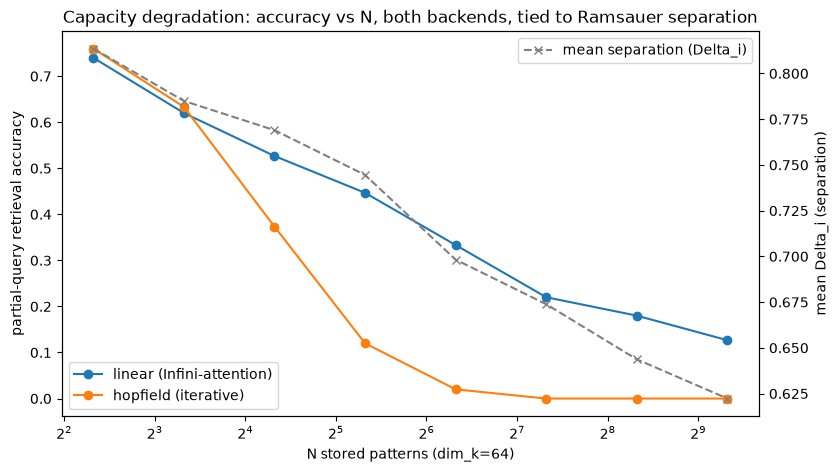

In [11]:
Ns_arr = [r["N"] for r in capacity_results]
lin_acc = [r["linear_acc"] for r in capacity_results]
hop_acc = [r["hopfield_acc"] for r in capacity_results]
deltas = [r["delta"] for r in capacity_results]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(Ns_arr, lin_acc, marker="o", label="linear (Infini-attention)")
ax1.plot(Ns_arr, hop_acc, marker="o", label="hopfield (iterative)")
ax1.set_xscale("log", base=2)
ax1.set_xlabel("N stored patterns (dim_k=64)")
ax1.set_ylabel("partial-query retrieval accuracy")
ax1.legend(loc="lower left")

ax2 = ax1.twinx()
ax2.plot(Ns_arr, deltas, marker="x", color="gray", linestyle="--", label="mean separation (Delta_i)")
ax2.set_ylabel("mean Delta_i (separation)")
ax2.legend(loc="upper right")

plt.title("Capacity degradation: accuracy vs N, both backends, tied to Ramsauer separation")
plt.show()

## Verdict

**Superseded by the confound-fix rerun — see experiments.md, "2026-07-07 (correction)" entry.**

Original take (below) turned out to be an artifact of a broken linear baseline. Kept for the
paper trail, not as the standing conclusion:

- ~~Hopfield clearly wins on ambiguous queries (3c) and at small N~~ — after fixing the linear
  backend's query-blindness (fixed centering projection, no learned params), linear ties Hopfield
  at N=5 (79% vs 81%) and is arguably better-calibrated on ambiguous queries (100% vs 79% top-2
  accuracy on the true pair).
- ~~Hopfield does not show durable capacity scaling~~ — true, but worse than that: the *fixed*
  linear backend clearly **outperforms** Hopfield from N=20 upward, and Hopfield hits 0% accuracy
  by N=160 while linear still gets ~13-22% correct even at N=320-640.
- The corrected, fair comparison does **not** support "iterative Hopfield retrieval beats
  single-shot linear retrieval on ambiguous/partial queries" as originally hypothesized. Clean
  negative — see experiments.md for the full numbers and caveats on what this test can and can't
  claim.
